# Problem C: Surrogate Modeling for Steady-State Heat Conduction in Heterogeneous Materials

Consider the steady-state heat conduction problem in a heterogeneous solid material occupying the unit square domain $\Omega = [0,1]^2$:

$$
\begin{split}
-\nabla\cdot(a(x,y)\nabla u) &= f,\quad (x,y)\in\Omega=[0,1]^2 \\
u &= 0,\quad (x,y)\in\partial\Omega
\end{split} \tag{2}
$$

where $u(x,y)$ denotes the temperature field, $a(x,y) > 0$ denotes the spatially varying thermal conductivity of the material, and the uniform heat source is given by $f = 10$. The zero Dirichlet boundary condition models a configuration in which the boundary of the domain is kept at a fixed reference temperature.

In computational materials science, evaluating the thermal response of a large number of candidate microstructures is a central bottleneck in material screening and design workflows. Although high-fidelity Finite Element Method (FEM) solvers can produce accurate solutions, they are computationally expensive when applied repeatedly to thousands of different conductivity fields $a(x,y)$.

## Task: Learning the Solution Operator $a(x,y) \mapsto u(x,y)$

The goal of this task is to make a fast prediction of the temperature field $u(x,y)$ given $a(x,y)$. To this end, a dataset of input-output pairs $\{a^{(j)}, u^{(j)}\}$ has been pre-computed using a high-precision FEM solver. The conductivity fields $a^{(j)}$ are sampled from a distribution $\mathcal{A}$ over spatially heterogeneous functions, representative of realistic microstructural variability in composite materials. Once trained, the model should accurately predict the temperature field for new, unseen conductivity samples drawn from the same distribution $\mathcal{A}$, at a fraction of the cost of a full FEM solve.

### Goals

- Please select a suitable deep learning method for this task and justify your choice.
- Report your implementation setup, including network architecture, activation function, optimizer (with learning rate), number of epochs, batch size, loss formulation, and any additional techniques used for improvement.
- Compute the $L^2$ relative error on the **test dataset** at each training epoch and plot the `Error vs. Epoch` curve (reporting the final error). The $L^2$ relative error between predictions $\{u^{(j)}_{\text{pred}}\}_{j=1}^{N}$ and ground truth $\{u^{(j)}_{\text{true}}\}_{j=1}^{N}$ is defined as:

$$
\text{error} = \frac{1}{N}\sum_{j=1}^{N}\sqrt{\frac{\sum_i\left|u^{(j)}_{\text{pred}}(x_i)-u^{(j)}_{\text{true}}(x_i)\right|^2}{\sum_i\left|u^{(j)}_{\text{true}}(x_i)\right|^2}}
$$

where $j$ indexes the sample and $i$ indexes the spatial grid point.

- For the **first test instance**, use `matplotlib` to plot the following in separate figures:
  1. The input conductivity field $a(x,y)$
  2. The predicted temperature field $u_{\text{pred}}(x,y)$
  3. The ground truth temperature field $u_{\text{true}}(x,y)$
  4. The pointwise absolute error $|u_{\text{pred}} - u_{\text{true}}|$

### Dataset

The training and test data are provided in `ProblemC_dataset.h5`:

| Key | Shape | Description |
|---|---|---|
| `a_train` | (1000, 128, 128) | Training conductivity fields sampled from $\mathcal{A}$ |
| `u_train` | (1000, 128, 128) | Corresponding FEM-computed temperature fields (training) |
| `a_test` | (200, 128, 128) | Test conductivity fields (for error evaluation only, **do not use for training**) |
| `u_test` | (200, 128, 128) | Corresponding FEM-computed temperature fields (test reference, **do not use for training**) |
| `X` | (128, 128) | $x$-coordinates of the $128\times 128$ regular spatial grid |
| `Y` | (128, 128) | $y$-coordinates of the $128\times 128$ regular spatial grid |

> 📥 Dataset download: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

In [1]:
#### LOAD DATA ####

import h5py
import numpy as np
import torch
import torch.nn as nn
from torch.autograd import grad, Variable
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

np.random.seed(67)
torch.manual_seed(67)

DEVICE        = torch.device('cuda')
DATA_TYPE     = torch.float32
LEARNING_RATE = 0.001
WEIGHT_DECAY  = 0.0001
EPOCHS        = 50
MODES_1       = 16
MODES_2       = 16
HIDDEN_LIST   = [40, 40, 40]

DATA_PATH = 'ProblemC_dataset.h5'

with h5py.File(DATA_PATH, 'r') as file:
    a_train = np.array(file['a_train'])
    u_train = np.array(file['u_train'])
    a_test  = np.array(file['a_test'])
    u_test  = np.array(file['u_test'])
    X       = np.array(file['X'])
    Y       = np.array(file['Y'])

a_train = torch.tensor(a_train, dtype=DATA_TYPE, device=DEVICE)
u_train = torch.tensor(u_train, dtype=DATA_TYPE, device=DEVICE)
a_test  = torch.tensor(a_test, dtype=DATA_TYPE, device=DEVICE)
u_test  = torch.tensor(u_test, dtype=DATA_TYPE, device=DEVICE)
X       = torch.tensor(X, dtype=DATA_TYPE, device=DEVICE)
Y       = torch.tensor(Y, dtype=DATA_TYPE, device=DEVICE)

In [2]:
#### DECLARE CLASSES ####

class SpectralConvolution(nn.Module):
    
    def __init__(self, in_size, out_size, modes1, modes2):
        super(SpectralConvolution, self).__init__()
        self.in_size = in_size 
        self.out_size = out_size 
        self.modes1 = modes1
        self.modes2 = modes2
        self.scale = 1./(in_size * out_size)
        ctype = torch.complex64
        self.weight1 = nn.Parameter(self.scale * torch.rand(in_size, out_size, self.modes1, self.modes2, dtype=ctype))
        self.weight2 = nn.Parameter(self.scale * torch.rand(in_size, out_size, self.modes1, self.modes2, dtype=ctype))

    def compl_mul_2d(self, input, weight):
        return torch.einsum("bixy, ioxy->boxy", input, weight)

    def forward(self, x):
        batch_size = x.shape[0]
        x_ft = torch.fft.rfft2(x)
        out_ft = torch.zeros(batch_size, self.out_size, x.size(-2), x.size(-1)//2+1, device=x.device, dtype=torch.cfloat)
        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul_2d(x_ft[:, :, :self.modes1, :self.modes2], self.weight1)
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul_2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weight2)
        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))

        return x
        
class FNO2D(nn.Module):
    def __init__(self, in_size, out_size, modes1, modes2, hidden_list:list[int], dtype=None):
        super(FNO2D, self).__init__()
        self.hidden_list = hidden_list
        self.activation = nn.ReLU()

        self.fc_in = nn.Linear(in_size, hidden_list[0], dtype=dtype)
        
        conv_net, w_net = [], []
        self.hidden_in = hidden_list[0]
        for hidden in hidden_list[1:]:
            conv_net.append(SpectralConvolution(self.hidden_in, hidden, modes1, modes2))
            w_net.append(nn.Conv2d(self.hidden_in, hidden, kernel_size=1, dtype=dtype))
            self.hidden_in = hidden 
            
        self.spectral_conv = nn.ModuleList(conv_net)
        self.weight_conv = nn.ModuleList(w_net)
        
        self.fc_out0 = nn.Linear(self.hidden_in, 128, dtype=dtype)
        self.fc_out1 = nn.Linear(128, out_size, dtype=dtype)
    
    def forward(self, ax):
        # Enforce boundary condition
        x_coord, y_coord = ax[..., 1], ax[..., 2]
        d = (x_coord * (1 - x_coord) * y_coord * (1 - y_coord)).unsqueeze(-1)
        
        ax = self.fc_in(ax)
        #(b, nx, ny, hidden) -> (b, hidden, nx, ny)
        ax = ax.permute(0, 3, 1, 2)
        
        for conv, weight in zip(self.spectral_conv, self.weight_conv):
            ax1 = conv(ax)
            ax2 = weight(ax)
            ax = self.activation(ax1 + ax2)
            
        # (b, hidden, nx, ny) -> (b, nx, ny, hidden)
        ax = ax.permute(0, 2, 3, 1)
        
        # Output projections
        ax = self.fc_out0(ax)
        ax = self.activation(ax)


        return d * self.fc_out1(ax)

class LossClass(object):

    def __init__(self, u_model):
        self.device = DEVICE
        self.u_model = u_model 
    
    def loss_data(self, ax_batch, u_batch):
        batch_size = u_batch.shape[0]
        ax, u = ax_batch.to(self.device), u_batch.to(self.device)
        u_pred = self.u_model(ax)
        loss = torch.norm(u.reshape(batch_size, -1)-u_pred.reshape(batch_size, -1), 2, 1)
        loss = torch.mean(loss)
        
        return loss 

    def get_error(self, ax, u):
        batch_size = u.shape[0]
        ax, u = ax.to(self.device), u.to(self.device)

        u_pred = self.u_model(ax)
        error = torch.norm(u.reshape(batch_size,-1)-u_pred.reshape(batch_size,-1), 2, 1) / torch.norm(u.reshape(batch_size,-1), 2, 1)

        return torch.mean(error)
    
class MyDataset(Dataset):

    def __init__(self, ax, uT):
        self.ax = ax
        self.uT = uT
    
    def __getitem__(self, index):
        return self.ax[index], self.uT[index]

    def __len__(self):
        return self.ax.shape[0]

In [3]:
#### AUXILIRY TENSORS AND OBJECTS ####

a_train = a_train.unsqueeze(-1)
u_train = u_train.unsqueeze(-1)

a_test = a_test.unsqueeze(-1)
u_test = u_test.unsqueeze(-1)

batch_size = a_train.shape[0]
test_size = a_test.shape[0]

X_ext = X.unsqueeze(0).unsqueeze(-1).expand(batch_size, -1, -1, -1)
Y_ext = Y.unsqueeze(0).unsqueeze(-1).expand(batch_size, -1, -1, -1)

X_test = X.unsqueeze(0).unsqueeze(-1).expand(test_size, -1, -1, -1)
Y_test = Y.unsqueeze(0).unsqueeze(-1).expand(test_size, -1, -1, -1)

ax_train = torch.cat([a_train, X_ext, Y_ext], dim=-1)
ax_test = torch.cat([a_test, X_test, Y_test], dim=-1)

in_channels = ax_train.shape[-1]  # (a, X, Y)
out_channels = u_train.shape[-1]  # (u)
u_model = FNO2D(in_channels, out_channels, MODES_1, MODES_2, HIDDEN_LIST, dtype=DATA_TYPE).to(DEVICE)

loader = DataLoader(MyDataset(ax_train, u_train), batch_size=50, shuffle=True)

OPTIMIZER = torch.optim.Adam(params=u_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
SCHEDULER = torch.optim.lr_scheduler.StepLR(OPTIMIZER, step_size=int(EPOCHS/4), gamma=0.5)

lossClass = LossClass(u_model)

In [4]:
#### TRAINING LOOP ####

loss_list, error_list = [], []
for epoch in range(EPOCHS):
    loss = 0.
    for ax_batch, u_batch in loader:
        loss_train = lossClass.loss_data(ax_batch, u_batch)
        
        OPTIMIZER.zero_grad()
        loss_train.backward()
        OPTIMIZER.step()
        
        loss += loss_train

    SCHEDULER.step()
    with torch.no_grad():
        error = lossClass.get_error(ax_test, u_test)
        error_list.append(error.item())

    loss = loss/len(loader)
    loss_list.append(loss.item())
    
    print(f'Epoch:{epoch}, The loss is:{loss.item()}, Current L^2 Error: {error_list[-1]}')

Epoch:0, The loss is:59.37309646606445, Current L^2 Error: 0.784245491027832
Epoch:1, The loss is:24.197200775146484, Current L^2 Error: 0.07083633542060852
Epoch:2, The loss is:6.31299352645874, Current L^2 Error: 0.07050558179616928
Epoch:3, The loss is:4.269307613372803, Current L^2 Error: 0.03372800350189209
Epoch:4, The loss is:3.642780303955078, Current L^2 Error: 0.033401623368263245
Epoch:5, The loss is:3.4294755458831787, Current L^2 Error: 0.03253120556473732
Epoch:6, The loss is:3.209252119064331, Current L^2 Error: 0.02530742436647415
Epoch:7, The loss is:2.9694221019744873, Current L^2 Error: 0.023787349462509155
Epoch:8, The loss is:2.7814502716064453, Current L^2 Error: 0.027508119121193886
Epoch:9, The loss is:2.649142265319824, Current L^2 Error: 0.026770399883389473
Epoch:10, The loss is:2.439786672592163, Current L^2 Error: 0.018714619800448418
Epoch:11, The loss is:2.277247428894043, Current L^2 Error: 0.01850416325032711
Epoch:12, The loss is:2.1842901706695557, Cu

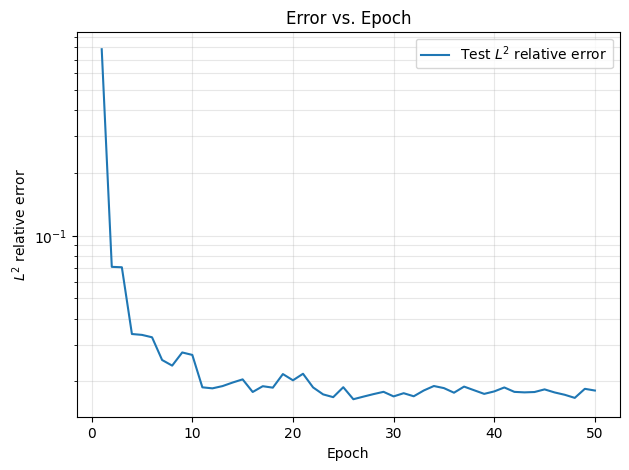

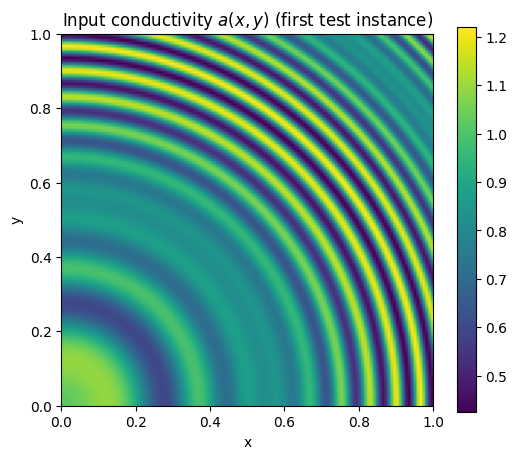

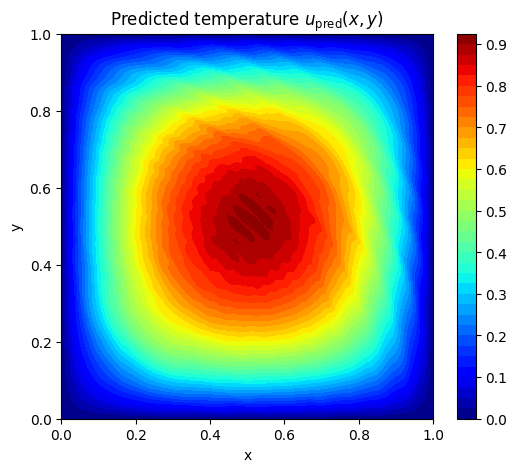

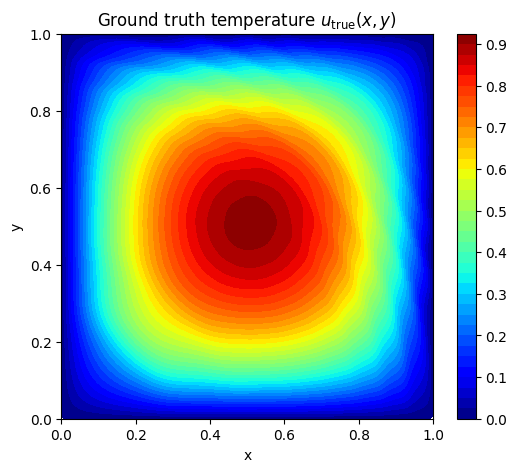

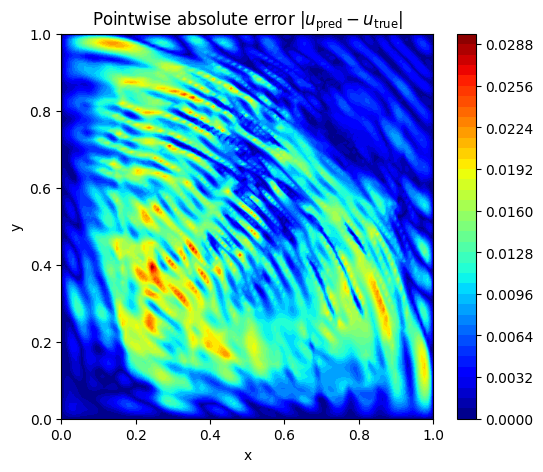

Final test L2 relative error after 50 epochs: 0.0181 (1.81%)


In [5]:
#### PLOTTING ####

u_model.eval()
with torch.no_grad():
    u_pred0 = u_model(ax_test[:1].to(DEVICE)).squeeze(-1).cpu()[0]
a0 = a_test.squeeze(-1).cpu()[0]
u_true0 = u_test.squeeze(-1).cpu()[0]
abs_err0 = (u_pred0 - u_true0).abs()

X_np = X.cpu().numpy()
Y_np = Y.cpu().numpy()

plt.figure(figsize=(7, 5))
plt.semilogy(range(1, EPOCHS + 1), error_list, label='Test $L^2$ relative error')
plt.xlabel('Epoch')
plt.ylabel('$L^2$ relative error')
plt.title('Error vs. Epoch')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

# Input conductivity field a(x,y)
plt.figure(figsize=(6, 5))
im = plt.imshow(a0, origin='lower', extent=(0, 1, 0, 1))
plt.colorbar(im)
plt.title('Input conductivity $a(x,y)$ (first test instance)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Predicted temperature field
plt.figure(figsize=(6, 5))
cs = plt.contourf(X_np, Y_np, u_pred0, levels=40, cmap='jet')
plt.colorbar(cs)
plt.title('Predicted temperature $u_{\\mathrm{pred}}(x,y)$')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Ground truth temperature field
plt.figure(figsize=(6, 5))
cs = plt.contourf(X_np, Y_np, u_true0, levels=40, cmap='jet')
plt.colorbar(cs)
plt.title('Ground truth temperature $u_{\\mathrm{true}}(x,y)$')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Pointwise absolute error
plt.figure(figsize=(6, 5))
cs = plt.contourf(X_np, Y_np, abs_err0, levels=40, cmap='jet')
plt.colorbar(cs)
plt.title('Pointwise absolute error $|u_{\\mathrm{pred}} - u_{\\mathrm{true}}|$')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

print(f'Final test L2 relative error after {EPOCHS} epochs: 'f'{error_list[-1]:.4f} ({error_list[-1]*100:.2f}%)')